# B9D54_10_Trần Văn Quang Khải_ATMobile

# Detecting Android Malware: From Neural Embeddings to Hands-On Validation with BERTroid

## Thực nghiệm mô hình cải tiến: DistilBERTroid-Permission

Nội dung chính gồm:

1. Tải và đọc **Android Permission Dataset** từ Kaggle.
2. Loại bỏ các cột metadata, chỉ giữ lại các cột permission dạng nhị phân.
3. Chuyển danh sách permission thành chuỗi văn bản.
4. Lấy mẫu cân bằng giữa hai lớp benign và malware.
5. Huấn luyện mô hình **DistilBERTroid-Permission**.
6. Theo dõi loss, Accuracy, Precision, Recall, F1-score, MCC theo từng epoch.
7. Áp dụng **early stopping** để tránh overfitting.
8. Đánh giá trên tập test và xuất bảng kết quả, biểu đồ, mô hình.

> Ghi chú: Mô hình này là biến thể của BERTroid, trong đó encoder `bert-base-uncased` được thay bằng `distilbert-base-uncased` để giảm chi phí huấn luyện và phù hợp hơn với Google Colab.

## 0. Gợi ý cấu hình chạy bản tối ưu

Notebook này là bản **tối ưu hóa** cho thực nghiệm DistilBERTroid-Permission trên Android Permission Dataset.

Các tối ưu đã bổ sung:

- **Tự lấy tối đa số mẫu cân bằng** giữa hai lớp benign/malware thay vì cố định 9.000 mẫu/lớp.
- **Tự ước lượng `MAX_LEN`** theo độ dài chuỗi permission để giảm padding thừa và tăng tốc.
- **Tokenize trước toàn bộ dữ liệu** thay vì tokenize từng mẫu trong `__getitem__`, giúp DataLoader nhanh và ổn định hơn.
- **Mixed precision AMP** khi có GPU, giúp giảm bộ nhớ và tăng tốc huấn luyện.
- **Learning rate phân biệt**: encoder DistilBERT dùng learning rate nhỏ hơn, classifier dùng learning rate lớn hơn.
- **Warmup scheduler** với `WARMUP_RATIO = 0.06`.
- **Early stopping** theo `val_loss` hoặc `val_f1`.
- **Tối ưu threshold dự đoán trên validation set** để cải thiện F1/Recall trên tập test.
- Bổ sung bảng kết quả: argmax, threshold tối ưu, AUC, PR-AUC, threshold tuning.

Cấu hình mặc định:

- `MAX_SAMPLES_PER_CLASS = None` → tự lấy tối đa số mẫu cân bằng.
- `MAX_LEN_MODE = "auto"` → tự chọn độ dài token hợp lý.
- `BATCH_SIZE = 32` nếu có GPU, `8` nếu CPU.
- `EPOCHS = 200`.
- `PATIENCE = 20`.
- `EARLY_STOP_METRIC = "val_loss"`.
- `MIN_DELTA = 1e-4`.
- `FREEZE_DISTILBERT = False`.

Lưu ý: `EPOCHS = 200` chỉ là **giới hạn tối đa**. Notebook dùng early stopping nên không bắt buộc chạy đủ 200 epoch.


In [ ]:
# Cài đặt thư viện transformers để sử dụng tokenizer và mô hình DistilBERT từ Hugging Face.
!pip install -q transformers accelerate kaggle

In [ ]:
# Import thư viện xử lý dữ liệu dạng bảng.
import pandas as pd

# Import thư viện tính toán số học.
import numpy as np

# Import thư viện vẽ biểu đồ.
import matplotlib.pyplot as plt

# Import thư viện tạo thư mục, kiểm tra file và xử lý đường dẫn.
import os

# Import thư viện sao chép file, dùng khi cấu hình Kaggle API.
import shutil

# Import thư viện random để cố định tính ngẫu nhiên.
import random

# Import thư viện json để lưu thông tin cấu hình nếu cần.
import json

# Import thư viện zipfile để nén các file kết quả nộp kèm.
import zipfile

# Import thư viện time để đo thời gian huấn luyện.
import time

# Import PyTorch để xây dựng và huấn luyện mô hình học sâu.
import torch

# Import neural network module của PyTorch.
import torch.nn as nn

# Import Dataset và DataLoader để quản lý dữ liệu theo batch.
from torch.utils.data import Dataset, DataLoader

# Import tokenizer nhanh của DistilBERT.
from transformers import DistilBertTokenizerFast

# Import encoder DistilBERT tiền huấn luyện.
from transformers import DistilBertModel

# Import scheduler tuyến tính với warmup từ Hugging Face.
from transformers import get_linear_schedule_with_warmup

# Import optimizer AdamW từ PyTorch.
from torch.optim import AdamW

# Import hàm chia dữ liệu train/validation/test.
from sklearn.model_selection import train_test_split

# Import các độ đo đánh giá mô hình phân loại.
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, matthews_corrcoef

# Import classification_report để in báo cáo chi tiết theo từng lớp.
from sklearn.metrics import classification_report

# Import confusion_matrix để tạo ma trận nhầm lẫn.
from sklearn.metrics import confusion_matrix

# Import ConfusionMatrixDisplay để trực quan hóa ma trận nhầm lẫn.
from sklearn.metrics import ConfusionMatrixDisplay

# Import ROC-AUC, PR-AUC và các curve để đánh giá mô hình ở mức xác suất.
from sklearn.metrics import roc_auc_score, average_precision_score, roc_curve, precision_recall_curve


In [ ]:
# Thiết lập seed để kết quả có thể tái lập tương đối giữa các lần chạy.
SEED = 42

# Cố định seed cho thư viện random của Python.
random.seed(SEED)

# Cố định seed cho NumPy.
np.random.seed(SEED)

# Cố định seed cho PyTorch trên CPU.
torch.manual_seed(SEED)

# Cố định seed cho PyTorch trên GPU nếu có.
torch.cuda.manual_seed_all(SEED)

# Bật chế độ tối ưu tốc độ khi chạy GPU.
# Khi FAST_TRAINING = True, kết quả có thể dao động rất nhỏ giữa các lần chạy nhưng tốc độ thường tốt hơn.
FAST_TRAINING = True

# Nếu ưu tiên tốc độ, cho phép cuDNN tự chọn thuật toán nhanh.
torch.backends.cudnn.benchmark = FAST_TRAINING

# Nếu ưu tiên tốc độ, không bắt buộc deterministic tuyệt đối.
torch.backends.cudnn.deterministic = not FAST_TRAINING

# Kiểm tra thiết bị: nếu có GPU thì dùng cuda, nếu không thì dùng CPU.
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# In thiết bị đang sử dụng.
print("Thiết bị sử dụng:", device)

# Nếu có GPU, in tên GPU đang được Colab cấp phát.
if torch.cuda.is_available():
    print("Tên GPU:", torch.cuda.get_device_name(0))

# Nếu dùng GPU, bật mixed precision để tăng tốc và giảm bộ nhớ.
USE_AMP = torch.cuda.is_available()

# In trạng thái mixed precision.
print("Sử dụng mixed precision:", USE_AMP)


Thiết bị sử dụng: cuda
Tên GPU: NVIDIA RTX PRO 6000 Blackwell Server Edition
Sử dụng mixed precision: True


## 1. Tải dữ liệu từ Kaggle

Phần này dùng file `kaggle.json` để tải **Android Permission Dataset**. Nếu bạn đã tải và giải nén dataset rồi, có thể chạy tiếp từ mục **2. Đọc dữ liệu CSV**.

In [ ]:
# Import công cụ upload file từ Google Colab.
from google.colab import files

# Kiểm tra xem kaggle.json đã tồn tại trong môi trường Colab chưa.
if not os.path.exists("/root/.kaggle/kaggle.json"):
    # Nếu chưa có, yêu cầu người dùng upload file kaggle.json.
    print("Vui lòng upload file kaggle.json từ tài khoản Kaggle.")
    uploaded = files.upload()

    # Tạo thư mục /root/.kaggle nếu chưa tồn tại.
    os.makedirs("/root/.kaggle", exist_ok=True)

    # Nếu người dùng đã upload kaggle.json, di chuyển file vào đúng thư mục.
    if "kaggle.json" in uploaded:
        shutil.move("kaggle.json", "/root/.kaggle/kaggle.json")

    # Cấp quyền đọc/ghi bảo mật cho file kaggle.json.
    os.chmod("/root/.kaggle/kaggle.json", 600)
else:
    # Nếu đã có kaggle.json, bỏ qua bước upload.
    print("Đã tìm thấy /root/.kaggle/kaggle.json")

Vui lòng upload file kaggle.json từ tài khoản Kaggle.


Saving kaggle.json to kaggle.json


In [ ]:
# Import subprocess để chạy lệnh hệ thống từ trong Python.
import subprocess

# Tạo thư mục chứa dữ liệu sau khi giải nén.
os.makedirs("android_permission_dataset", exist_ok=True)

# Kiểm tra nếu thư mục chưa có file CSV thì tải dataset từ Kaggle.
if len(os.listdir("android_permission_dataset")) == 0:
    # Tải Android Permission Dataset từ Kaggle bằng Kaggle CLI.
    subprocess.run(
        ["kaggle", "datasets", "download", "-d", "saurabhshahane/android-permission-dataset"],
        check=True
    )

    # Giải nén file zip vào thư mục android_permission_dataset.
    subprocess.run(
        ["unzip", "-o", "android-permission-dataset.zip", "-d", "android_permission_dataset"],
        check=True
    )
else:
    # Nếu đã có dữ liệu, không tải lại để tiết kiệm thời gian.
    print("Thư mục android_permission_dataset đã có dữ liệu, bỏ qua bước tải lại.")

# In danh sách file trong thư mục dữ liệu.
print(os.listdir("android_permission_dataset"))

['__notebook_source__.ipynb', 'Android_Permission.csv']


## 2. Đọc dữ liệu CSV và khảo sát cấu trúc ban đầu

In [ ]:
# Liệt kê toàn bộ file trong thư mục dataset.
dataset_files = os.listdir("android_permission_dataset")

# Lọc ra các file có đuôi .csv.
csv_files = [file for file in dataset_files if file.lower().endswith(".csv")]

# Kiểm tra nếu không tìm thấy file CSV thì dừng lại.
if len(csv_files) == 0:
    raise FileNotFoundError("Không tìm thấy file CSV trong thư mục android_permission_dataset.")

# Chọn file CSV đầu tiên tìm được.
csv_path = os.path.join("android_permission_dataset", csv_files[0])

# In đường dẫn file đang sử dụng.
print("Đường dẫn file CSV:", csv_path)

# Đọc dữ liệu gốc bằng pandas.
df_raw = pd.read_csv(csv_path)

# Hiển thị 5 dòng đầu tiên để kiểm tra nhanh.
df_raw.head()

Đường dẫn file CSV: android_permission_dataset/Android_Permission.csv


,App,Package,Category,Description,Rating,Number of ratings,Price,Related apps,Dangerous permissions count,Safe permissions count,...,Your personal information : read calendar events (D),Your personal information : read contact data (D),Your personal information : read sensitive log data (D),Your personal information : read user defined dictionary (D),Your personal information : retrieve system internal state (S),Your personal information : set alarm in alarm clock (S),Your personal information : write Browser's history and bookmarks (D),Your personal information : write contact data (D),Your personal information : write to user defined dictionary (S),Class
0,Canada Post Corporation,com.canadapost.android,Business,Canada Post Mobile App gives you access to som...,3.1,77,0.00,"{com.adaffix.pub.ca.android, com.kevinquan.gas...",7.0,1,...,0,1,0,0,0,0,0,1,0,0
1,Word Farm,com.realcasualgames.words,Brain & Puzzle,Speed and strategy combine in this exciting wo...,4.3,199,0.00,"{air.com.zubawing.FastWordLite, com.joybits.do...",3.0,2,...,0,0,0,0,0,0,0,0,0,0
2,Fortunes of War FREE,fortunesofwar.free,Cards & Casino,"Fortunes of War is a fast-paced, easy to learn...",4.1,243,0.00,"{com.kevinquan.condado, hu.monsta.pazaak, net....",1.0,1,...,0,0,0,0,0,0,0,0,0,0
3,Better Keyboard: Avatar Purple,com.cc.betterkeyboard.skins.avatarpurple,Libraries & Demo,Skin for Better Keyboard featuring a glossy fe...,3.6,2589,0.00,{eu.gdumoulin.betterandroid.skins.transparent....,0.0,0,...,0,0,0,0,0,0,0,0,0,0
4,Boxing Day,indiaNIC.android.BoxingDay,Lifestyle,Boxing Day by Christopher Jaymes<p>Based on a ...,0.0,0,5.99,NaN,1.0,0,...,0,0,0,0,0,0,0,0,0,1


In [ ]:
# In kích thước dữ liệu gốc: số dòng và số cột.
print("Kích thước dữ liệu gốc:", df_raw.shape)

# In danh sách cột trong dataset.
print("\nDanh sách cột:")
print(df_raw.columns.tolist())

# Kiểm tra số lượng giá trị thiếu của 15 cột đầu tiên.
print("\nSố lượng giá trị thiếu ở 15 cột đầu tiên:")
print(df_raw.isnull().sum().head(15))

# Hiển thị kiểu dữ liệu của 15 cột đầu tiên.
print("\nKiểu dữ liệu của 15 cột đầu tiên:")
print(df_raw.dtypes.head(15))

Kích thước dữ liệu gốc: (29999, 184)

Danh sách cột:
['App', 'Package', 'Category', 'Description', 'Rating', 'Number of ratings', 'Price', 'Related apps', 'Dangerous permissions count', 'Safe permissions count', 'Default : Access DRM content. (S)', 'Default : Access Email provider data (S)', 'Default : Access all system downloads (S)', 'Default : Access download manager. (S)', 'Default : Advanced download manager functions. (S)', 'Default : Audio File Access (S)', 'Default : Install DRM content. (S)', 'Default : Modify Google service configuration (S)', 'Default : Modify Google settings (S)', 'Default : Move application resources (S)', 'Default : Read Google settings (S)', 'Default : Send download notifications. (S)', 'Default : Voice Search Shortcuts (S)', 'Default : access SurfaceFlinger (S)', 'Default : access checkin properties (S)', 'Default : access the cache filesystem (S)', 'Default : access to passwords for Google accounts (S)', 'Default : act as an account authenticator (S)',

## 3. Xác định và chuẩn hóa nhãn

Trong Android Permission Dataset, cột nhãn thường là `Class`, với quy ước:

- `0`: benign / ứng dụng lành tính
- `1`: malware / ứng dụng độc hại

In [ ]:
# Danh sách các tên cột nhãn thường gặp trong dataset malware.
possible_label_cols = ["Class", "class", "Label", "label", "Result", "result", "Type", "type"]

# Khởi tạo biến lưu tên cột nhãn.
label_col = None

# Duyệt qua từng tên cột có thể là nhãn.
for col in possible_label_cols:
    # Nếu cột đó tồn tại trong dữ liệu, chọn làm cột nhãn.
    if col in df_raw.columns:
        label_col = col
        break

# Nếu không tìm thấy cột nhãn, thông báo lỗi để người dùng tự kiểm tra.
if label_col is None:
    raise ValueError("Không tìm thấy cột nhãn. Hãy kiểm tra lại danh sách cột trong df_raw.columns.")

# In tên cột nhãn tìm được.
print("Cột nhãn tìm được:", label_col)

# In phân bố giá trị nhãn ban đầu.
print("\nPhân bố nhãn ban đầu:")
print(df_raw[label_col].value_counts(dropna=False))

Cột nhãn tìm được: Class

Phân bố nhãn ban đầu:
Class
1    20000
0     9999
Name: count, dtype: int64


In [ ]:
# Tạo bản sao từ dữ liệu gốc để xử lý.
df = df_raw.copy()

# Chuyển cột nhãn về kiểu số nguyên.
df["label"] = df[label_col].astype(int)

# Kiểm tra lại phân bố nhãn sau khi chuẩn hóa.
print("Phân bố nhãn sau chuẩn hóa:")
print(df["label"].value_counts())

# Tạo bảng mô tả nhanh nhãn để đưa vào báo cáo.
label_summary = pd.DataFrame({
    "label": [0, 1],
    "ý nghĩa": ["Benign", "Malware"],
    "số lượng": [int((df["label"] == 0).sum()), int((df["label"] == 1).sum())]
})

# Hiển thị bảng mô tả nhãn.
label_summary

Phân bố nhãn sau chuẩn hóa:
label
1    20000
0     9999
Name: count, dtype: int64


,label,ý nghĩa,số lượng
0,0,Benign,9999
1,1,Malware,20000


## 4. Loại bỏ metadata và lọc các cột permission

Các cột như `App`, `Package`, `Category`, `Description`, `Rating`, `Price` là metadata. Nếu đưa các cột này vào mô hình, thực nghiệm sẽ không còn bám sát hướng **permission-based** của BERTroid. Vì vậy, notebook chỉ giữ lại các cột permission dạng nhị phân 0/1.

In [ ]:
# Danh sách các cột metadata không dùng làm permission.
metadata_cols = [
    "App",
    "Package",
    "Category",
    "Description",
    "Rating",
    "Number of ratings",
    "Price",
    "Related apps",
    "Dangerous permissions count",
    "Safe permissions count",
    label_col,
    "label"
]

# Lọc các cột ứng viên bằng cách loại bỏ metadata và nhãn.
candidate_cols = [col for col in df.columns if col not in metadata_cols]

# In số lượng cột ứng viên.
print("Số cột ứng viên permission:", len(candidate_cols))

# In 20 cột đầu tiên để kiểm tra trực quan.
print("20 cột ứng viên đầu tiên:")
print(candidate_cols[:20])

Số cột ứng viên permission: 173
20 cột ứng viên đầu tiên:
['Default : Access DRM content. (S)', 'Default : Access Email provider data (S)', 'Default : Access all system downloads (S)', 'Default : Access download manager. (S)', 'Default : Advanced download manager functions. (S)', 'Default : Audio File Access (S)', 'Default : Install DRM content. (S)', 'Default : Modify Google service configuration (S)', 'Default : Modify Google settings (S)', 'Default : Move application resources (S)', 'Default : Read Google settings (S)', 'Default : Send download notifications. (S)', 'Default : Voice Search Shortcuts (S)', 'Default : access SurfaceFlinger (S)', 'Default : access checkin properties (S)', 'Default : access the cache filesystem (S)', 'Default : access to passwords for Google accounts (S)', 'Default : act as an account authenticator (S)', 'Default : bind to a wallpaper (S)', 'Default : bind to an input method (S)']


In [ ]:
# Định nghĩa hàm kiểm tra một cột có phải dạng nhị phân 0/1 hay không.
def is_binary_column(series):
    # Lấy các giá trị khác rỗng trong cột.
    values = series.dropna().unique()

    # Chuẩn hóa các giá trị về chuỗi viết thường để kiểm tra thống nhất.
    normalized_values = set(str(v).strip().lower() for v in values)

    # Tập giá trị hợp lệ cho cột nhị phân.
    allowed_values = {"0", "1", "0.0", "1.0", "true", "false"}

    # Trả về True nếu toàn bộ giá trị đều thuộc tập hợp hợp lệ.
    return normalized_values.issubset(allowed_values)

# Lọc ra các cột permission nhị phân.
permission_cols = [col for col in candidate_cols if is_binary_column(df[col])]

# Kiểm tra xem metadata có bị lọt vào permission_cols không.
leaked_cols = [col for col in permission_cols if col in metadata_cols]

# In số lượng cột permission sau khi lọc.
print("Số cột permission nhị phân sau khi lọc:", len(permission_cols))

# In metadata bị lọt nếu có.
print("Các cột metadata bị lọt vào permission_cols:", leaked_cols)

# In 10 cột permission đầu tiên.
for col in permission_cols[:10]:
    print("Cột:", col)
    print(df[col].value_counts().head())
    print("-" * 60)

Số cột permission nhị phân sau khi lọc: 173
Các cột metadata bị lọt vào permission_cols: []
Cột: Default : Access DRM content. (S)
Default : Access DRM content. (S)
0    29990
1        9
Name: count, dtype: int64
------------------------------------------------------------
Cột: Default : Access Email provider data (S)
Default : Access Email provider data (S)
0    29978
1       21
Name: count, dtype: int64
------------------------------------------------------------
Cột: Default : Access all system downloads (S)
Default : Access all system downloads (S)
0    29999
Name: count, dtype: int64
------------------------------------------------------------
Cột: Default : Access download manager. (S)
Default : Access download manager. (S)
0    29987
1       12
Name: count, dtype: int64
------------------------------------------------------------
Cột: Default : Advanced download manager functions. (S)
Default : Advanced download manager functions. (S)
0    29998
1        1
Name: count, dtype: in

## 5. Chuyển permission dạng cột nhị phân thành chuỗi văn bản

Mỗi ứng dụng sẽ được biểu diễn dưới dạng chuỗi permission. Ví dụ:

```text
network_communication_full_internet_access_d hardware_controls_control_vibrator_s
```

Cách biểu diễn này phù hợp với mô hình Transformer vì chuỗi permission được xử lý tương tự một chuỗi văn bản.

In [ ]:
# Hàm kiểm tra permission có xuất hiện trong một ứng dụng hay không.
def is_permission_present(value):
    # Nếu giá trị bị thiếu, xem như permission không xuất hiện.
    if pd.isna(value):
        return False

    # Nếu giá trị là số, chỉ 1 được xem là xuất hiện.
    if isinstance(value, (int, float)):
        return int(value) == 1

    # Nếu giá trị là chuỗi, chuẩn hóa về chữ thường.
    value_str = str(value).strip().lower()

    # Các giá trị biểu diễn permission xuất hiện.
    return value_str in ["1", "1.0", "true", "yes", "y"]

# Hàm chuẩn hóa tên permission thành token văn bản.
def clean_permission_name(permission_name):
    # Chuyển tên permission về chuỗi.
    permission_name = str(permission_name)

    # Xóa tiền tố phổ biến nếu có.
    permission_name = permission_name.replace("android.permission.", "")
    permission_name = permission_name.replace("Android.permission.", "")

    # Thay các ký tự phân cách bằng khoảng trắng.
    permission_name = permission_name.replace(":", " ")
    permission_name = permission_name.replace(".", " ")
    permission_name = permission_name.replace("-", " ")
    permission_name = permission_name.replace("(", " ")
    permission_name = permission_name.replace(")", " ")
    permission_name = permission_name.replace("/", " ")

    # Chuyển về chữ thường vì dùng distilbert-base-uncased.
    permission_name = permission_name.lower()

    # Tách theo khoảng trắng rồi ghép lại bằng dấu gạch dưới.
    permission_name = "_".join(permission_name.split())

    # Trả về token permission đã chuẩn hóa.
    return permission_name

# Tạo dictionary ánh xạ tên cột gốc sang token permission đã chuẩn hóa.
permission_name_map = {col: clean_permission_name(col) for col in permission_cols}

# Hàm chuyển một dòng dữ liệu thành chuỗi permission.
def row_to_permission_text(row):
    # Khởi tạo danh sách permission xuất hiện trong ứng dụng hiện tại.
    permissions = []

    # Duyệt từng cột permission.
    for col in permission_cols:
        # Nếu permission có giá trị 1, thêm token permission vào danh sách.
        if is_permission_present(row[col]):
            permissions.append(permission_name_map[col])

    # Ghép danh sách permission thành một chuỗi văn bản.
    return " ".join(permissions)

# Tạo DataFrame mới đúng định dạng cho mô hình.
df_bertroid = pd.DataFrame()

# Dùng Package làm app_id nếu dataset có cột Package.
if "Package" in df.columns:
    df_bertroid["app_id"] = df["Package"].astype(str)
else:
    df_bertroid["app_id"] = [f"app_{i:06d}" for i in range(len(df))]

# Thay thế app_id thiếu bằng mã tự động.
missing_app_id_mask = df_bertroid["app_id"].isin(["nan", "", "None"])

# Tạo mã tự động cho các app thiếu Package.
df_bertroid.loc[missing_app_id_mask, "app_id"] = [f"app_{i:06d}" for i in range(missing_app_id_mask.sum())]

# Chuyển từng dòng thành chuỗi permission.
df_bertroid["permissions"] = df.apply(row_to_permission_text, axis=1)

# Gán nhãn 0/1.
df_bertroid["label"] = df["label"].values

# Loại bỏ các dòng không có permission nào.
df_bertroid = df_bertroid[df_bertroid["permissions"] != ""].reset_index(drop=True)

# Tính số permission trên mỗi ứng dụng.
df_bertroid["num_permissions"] = df_bertroid["permissions"].apply(lambda text: len(text.split()))

# Lưu dữ liệu đã chuyển đổi.
df_bertroid.to_csv("permissions_dataset.csv", index=False)

# Hiển thị 10 dòng đầu tiên.
df_bertroid.head(10)

,app_id,permissions,label,num_permissions
0,com.canadapost.android,network_communication_full_internet_access_d n...,0,8
1,com.realcasualgames.words,network_communication_full_internet_access_d n...,0,5
2,fortunesofwar.free,network_communication_full_internet_access_d n...,0,2
3,indiaNIC.android.BoxingDay,network_communication_full_internet_access_d,1,1
4,tmc.christmaslady.livewallpaper,network_communication_full_internet_access_d n...,0,4
5,ru.uralgames.solitaire.android,network_communication_full_internet_access_d n...,0,2
6,com.RunnerGames.game.PumpkinsVsMonster_AD,hardware_controls_control_vibrator_s network_c...,0,3
7,coder.hamster.jpall.cats,network_communication_full_internet_access_d s...,0,2
8,com.g5e.paranormal,network_communication_full_internet_access_d n...,0,4
9,com.jnj.mocospace.android,hardware_controls_control_vibrator_s network_c...,1,9


In [ ]:
# Tạo bảng tổng hợp dữ liệu sau chuyển đổi.
processed_summary = pd.DataFrame({
    "Thuộc tính": [
        "Số mẫu sau chuyển đổi",
        "Số cột trong dữ liệu mô hình",
        "Số mẫu benign",
        "Số mẫu malware",
        "Số permission trung bình/app",
        "Số permission nhỏ nhất/app",
        "Số permission lớn nhất/app"
    ],
    "Giá trị": [
        len(df_bertroid),
        df_bertroid.shape[1],
        int((df_bertroid["label"] == 0).sum()),
        int((df_bertroid["label"] == 1).sum()),
        round(df_bertroid["num_permissions"].mean(), 2),
        int(df_bertroid["num_permissions"].min()),
        int(df_bertroid["num_permissions"].max())
    ]
})

# Hiển thị bảng tổng hợp để đưa vào báo cáo.
processed_summary

,Thuộc tính,Giá trị
0,Số mẫu sau chuyển đổi,26257.00
1,Số cột trong dữ liệu mô hình,4.00
2,Số mẫu benign,9141.00
3,Số mẫu malware,17116.00
4,Số permission trung bình/app,5.07
5,Số permission nhỏ nhất/app,1.00
6,Số permission lớn nhất/app,41.00


## 6. Lấy mẫu cân bằng cho thực nghiệm

Dữ liệu gốc có thể mất cân bằng giữa benign và malware. Để mô hình không thiên lệch về lớp có nhiều mẫu hơn, notebook lấy mẫu cân bằng giữa hai lớp.

In [ ]:
# Số mẫu tối đa lấy từ mỗi lớp.
# None nghĩa là tự lấy tối đa số mẫu cân bằng theo lớp ít hơn.
# Ví dụ nếu có 9.999 benign và 20.000 malware, notebook sẽ lấy 9.999 mẫu mỗi lớp.
MAX_SAMPLES_PER_CLASS = None

# Nếu chạy CPU hoặc muốn thử nhanh, có thể đặt:
# MAX_SAMPLES_PER_CLASS = 500

# Lọc các mẫu benign.
df_benign = df_bertroid[df_bertroid["label"] == 0]

# Lọc các mẫu malware.
df_malware = df_bertroid[df_bertroid["label"] == 1]

# Tính số mẫu tối đa cân bằng có thể lấy.
max_balanced_samples = min(len(df_benign), len(df_malware))

# Nếu MAX_SAMPLES_PER_CLASS = None, dùng toàn bộ số mẫu cân bằng tối đa.
if MAX_SAMPLES_PER_CLASS is None:
    samples_per_class = max_balanced_samples
else:
    samples_per_class = min(MAX_SAMPLES_PER_CLASS, max_balanced_samples)

# In thông tin lấy mẫu.
print("Số mẫu benign có sẵn:", len(df_benign))
print("Số mẫu malware có sẵn:", len(df_malware))
print("Số mẫu mỗi lớp được dùng:", samples_per_class)

# Lấy mẫu ngẫu nhiên từ lớp benign.
df_benign_sample = df_benign.sample(
    n=samples_per_class,
    random_state=SEED
)

# Lấy mẫu ngẫu nhiên từ lớp malware.
df_malware_sample = df_malware.sample(
    n=samples_per_class,
    random_state=SEED
)

# Ghép hai lớp lại thành tập thực nghiệm.
df_exp = pd.concat([df_benign_sample, df_malware_sample], axis=0)

# Xáo trộn toàn bộ tập thực nghiệm.
df_exp = df_exp.sample(frac=1, random_state=SEED).reset_index(drop=True)

# Lưu dữ liệu thực nghiệm.
df_exp.to_csv("permissions_dataset_experiment.csv", index=False)

# Tạo bảng mô tả dữ liệu thực nghiệm.
experiment_summary = pd.DataFrame({
    "Thuộc tính": [
        "Tổng số mẫu thực nghiệm",
        "Số mẫu benign",
        "Số mẫu malware",
        "Số permission trung bình/app",
        "Số permission nhỏ nhất/app",
        "Số permission lớn nhất/app",
        "Chế độ lấy mẫu"
    ],
    "Giá trị": [
        len(df_exp),
        int((df_exp["label"] == 0).sum()),
        int((df_exp["label"] == 1).sum()),
        round(df_exp["num_permissions"].mean(), 2),
        int(df_exp["num_permissions"].min()),
        int(df_exp["num_permissions"].max()),
        "Tối đa cân bằng" if MAX_SAMPLES_PER_CLASS is None else f"Tối đa {MAX_SAMPLES_PER_CLASS}/lớp"
    ]
})

# Lưu bảng mô tả dữ liệu thực nghiệm.
experiment_summary.to_csv("data_summary.csv", index=False)

# Hiển thị bảng mô tả dữ liệu thực nghiệm.
experiment_summary


Số mẫu benign có sẵn: 9141
Số mẫu malware có sẵn: 17116
Số mẫu mỗi lớp được dùng: 9141


,Thuộc tính,Giá trị
0,Tổng số mẫu thực nghiệm,18282
1,Số mẫu benign,9141
2,Số mẫu malware,9141
3,Số permission trung bình/app,5.1
4,Số permission nhỏ nhất/app,1
5,Số permission lớn nhất/app,41
6,Chế độ lấy mẫu,Tối đa cân bằng


## 7. Chia dữ liệu train/validation/test

Dữ liệu được chia theo tỷ lệ:

- 70% train
- 15% validation
- 15% test

Tham số `stratify` được sử dụng để giữ tỷ lệ benign/malware cân bằng ở cả ba tập.

In [ ]:
# Lấy chuỗi permission làm đầu vào.
texts = df_exp["permissions"].values

# Lấy nhãn 0/1 làm đầu ra.
labels = df_exp["label"].values

# Chia dữ liệu thành 70% train và 30% tạm thời.
X_train, X_temp, y_train, y_temp = train_test_split(
    texts,
    labels,
    test_size=0.30,
    random_state=SEED,
    stratify=labels
)

# Chia 30% tạm thời thành 15% validation và 15% test.
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=SEED,
    stratify=y_temp
)

# Tạo bảng phân bố dữ liệu sau chia.
split_summary = pd.DataFrame({
    "Tập dữ liệu": ["Train", "Validation", "Test"],
    "Số mẫu": [len(X_train), len(X_val), len(X_test)],
    "Benign": [int((y_train == 0).sum()), int((y_val == 0).sum()), int((y_test == 0).sum())],
    "Malware": [int((y_train == 1).sum()), int((y_val == 1).sum()), int((y_test == 1).sum())]
})

# Hiển thị bảng phân bố dữ liệu.
split_summary

,Tập dữ liệu,Số mẫu,Benign,Malware
0,Train,12797,6398,6399
1,Validation,2742,1371,1371
2,Test,2743,1372,1371


## 8. Tokenizer và Dataset/DataLoader

In [ ]:
# Tên mô hình tiền huấn luyện được sử dụng.
MODEL_NAME = "distilbert-base-uncased"

# Khởi tạo tokenizer của DistilBERT.
tokenizer = DistilBertTokenizerFast.from_pretrained(MODEL_NAME)

# Chế độ chọn MAX_LEN.
# "auto": tự ước lượng theo phân vị 95% độ dài token của dữ liệu.
# "manual": dùng giá trị MAX_LEN_MANUAL.
MAX_LEN_MODE = "auto"

# Độ dài thủ công nếu MAX_LEN_MODE = "manual".
MAX_LEN_MANUAL = 128

# Hàm làm tròn lên bội số của 8 để tối ưu tensor core trên GPU.
def round_up_to_multiple(value, multiple=8):
    return int(np.ceil(value / multiple) * multiple)

# Nếu dùng auto, lấy một mẫu dữ liệu để ước lượng độ dài token.
if MAX_LEN_MODE == "auto":
    # Lấy tối đa 2.000 chuỗi để ước lượng nhanh, tránh tokenize toàn bộ chỉ để đo độ dài.
    length_sample = pd.Series(df_exp["permissions"]).sample(
        n=min(2000, len(df_exp)),
        random_state=SEED
    ).tolist()

    # Tokenize không padding để đo độ dài thật của từng chuỗi.
    token_lengths = [
        len(tokenizer.encode(text, add_special_tokens=True, truncation=False))
        for text in length_sample
    ]

    # Lấy phân vị 95% để hạn chế padding thừa nhưng vẫn giữ phần lớn thông tin.
    p95_len = int(np.percentile(token_lengths, 95))

    # Giới hạn trong khoảng 64-128 để cân bằng tốc độ và thông tin.
    MAX_LEN = min(128, max(64, round_up_to_multiple(p95_len + 8, 8)))
else:
    # Nếu dùng manual, lấy giá trị do người dùng đặt.
    MAX_LEN = MAX_LEN_MANUAL

# In MAX_LEN được chọn.
print("MAX_LEN được sử dụng:", MAX_LEN)

# Lấy thử một chuỗi permission để kiểm tra tokenizer.
sample_text = X_train[0]

# Tokenize thử chuỗi permission.
sample_encoding = tokenizer(
    sample_text,
    add_special_tokens=True,
    max_length=MAX_LEN,
    padding="max_length",
    truncation=True,
    return_attention_mask=True,
    return_tensors="pt"
)

# In chuỗi permission mẫu.
print("Chuỗi permission mẫu:", sample_text)

# In kích thước input_ids.
print("Kích thước input_ids:", sample_encoding["input_ids"].shape)

# In kích thước attention_mask.
print("Kích thước attention_mask:", sample_encoding["attention_mask"].shape)


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

MAX_LEN được sử dụng: 128
Chuỗi permission mẫu: network_communication_full_internet_access_d
Kích thước input_ids: torch.Size([1, 128])
Kích thước attention_mask: torch.Size([1, 128])


In [ ]:
# Định nghĩa Dataset dùng dữ liệu đã được tokenize trước.
# Cách này nhanh hơn tokenize trong __getitem__, đặc biệt khi train nhiều epoch.
class EncodedPermissionDataset(Dataset):
    # Hàm khởi tạo Dataset.
    def __init__(self, encodings, labels):
        # Lưu input_ids đã tokenize.
        self.input_ids = encodings["input_ids"]

        # Lưu attention_mask đã tokenize.
        self.attention_mask = encodings["attention_mask"]

        # Chuyển labels thành tensor long cho CrossEntropyLoss.
        self.labels = torch.tensor(labels, dtype=torch.long)

    # Hàm trả về số mẫu trong Dataset.
    def __len__(self):
        return len(self.labels)

    # Hàm lấy một mẫu dữ liệu theo chỉ số idx.
    def __getitem__(self, idx):
        return {
            "input_ids": self.input_ids[idx],
            "attention_mask": self.attention_mask[idx],
            "labels": self.labels[idx]
        }

# Hàm tokenize hàng loạt chuỗi permission.
def tokenize_texts(texts, tokenizer, max_len):
    # Chuyển input về list string để tokenizer xử lý ổn định.
    texts = [str(text) for text in texts]

    # Tokenize theo batch, padding/truncation về cùng độ dài.
    encodings = tokenizer(
        texts,
        add_special_tokens=True,
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
        return_tensors="pt"
    )

    return encodings


In [ ]:
# Batch size khi huấn luyện.
# Nếu có GPU, dùng 32 để tận dụng GPU tốt hơn; nếu CPU, dùng 8 để tránh quá chậm/bộ nhớ cao.
BATCH_SIZE = 32 if torch.cuda.is_available() else 8

# Nếu bị lỗi thiếu bộ nhớ GPU, giảm BATCH_SIZE xuống 16 hoặc 8.
# BATCH_SIZE = 16

# Tokenize trước toàn bộ tập train.
train_encodings = tokenize_texts(X_train, tokenizer, MAX_LEN)

# Tokenize trước toàn bộ tập validation.
val_encodings = tokenize_texts(X_val, tokenizer, MAX_LEN)

# Tokenize trước toàn bộ tập test.
test_encodings = tokenize_texts(X_test, tokenizer, MAX_LEN)

# Tạo Dataset cho tập train từ dữ liệu đã tokenize.
train_dataset = EncodedPermissionDataset(train_encodings, y_train)

# Tạo Dataset cho tập validation từ dữ liệu đã tokenize.
val_dataset = EncodedPermissionDataset(val_encodings, y_val)

# Tạo Dataset cho tập test từ dữ liệu đã tokenize.
test_dataset = EncodedPermissionDataset(test_encodings, y_test)

# Vì dữ liệu đã tokenize sẵn và nằm trong RAM, num_workers=0 thường ổn định hơn trên Colab.
NUM_WORKERS = 0

# Pin memory giúp chuyển tensor sang GPU nhanh hơn nếu đang dùng CUDA.
PIN_MEMORY = torch.cuda.is_available()

# Tạo DataLoader cho tập train.
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

# Tạo DataLoader cho tập validation.
val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

# Tạo DataLoader cho tập test.
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY
)

# In số batch train.
print("Số batch train:", len(train_loader))

# In số batch validation.
print("Số batch validation:", len(val_loader))

# In số batch test.
print("Số batch test:", len(test_loader))


Số batch train: 400
Số batch validation: 86
Số batch test: 86


## 9. Mô hình DistilBERTroid-Permission

Kiến trúc mô hình mới:

```text
Permission text
→ DistilBERT Tokenizer
→ DistilBERT Encoder
→ Hidden state của token đầu tiên
→ Dropout
→ Linear 768 → 128
→ ReLU
→ Linear 128 → 2
→ Benign / Malware
```

In [ ]:
# Định nghĩa mô hình DistilBERTroid-Permission.
class DistilBERTroidPermission(nn.Module):
    # Hàm khởi tạo mô hình.
    def __init__(self, model_name, num_classes=2, dropout_rate=0.3):
        # Gọi hàm khởi tạo của lớp cha nn.Module.
        super(DistilBERTroidPermission, self).__init__()

        # Tải DistilBERT encoder tiền huấn luyện.
        self.distilbert = DistilBertModel.from_pretrained(model_name)

        # Dropout giúp giảm overfitting.
        self.dropout = nn.Dropout(dropout_rate)

        # Lớp tuyến tính thứ nhất chuyển vector 768 chiều thành 128 chiều.
        self.fc1 = nn.Linear(768, 128)

        # Hàm kích hoạt ReLU tạo tính phi tuyến.
        self.relu = nn.ReLU()

        # Lớp đầu ra chuyển 128 chiều thành 2 lớp.
        self.fc2 = nn.Linear(128, num_classes)

    # Hàm forward mô tả luồng dữ liệu qua mô hình.
    def forward(self, input_ids, attention_mask):
        # Đưa input qua DistilBERT encoder.
        outputs = self.distilbert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        # Lấy hidden state của token đầu tiên làm vector đại diện chuỗi.
        cls_embedding = outputs.last_hidden_state[:, 0, :]

        # Áp dụng dropout.
        x = self.dropout(cls_embedding)

        # Qua lớp tuyến tính 768 → 128.
        x = self.fc1(x)

        # Qua hàm kích hoạt ReLU.
        x = self.relu(x)

        # Qua lớp tuyến tính cuối cùng 128 → 2.
        logits = self.fc2(x)

        # Trả về logits, chưa qua softmax.
        return logits

In [ ]:
# Khởi tạo mô hình DistilBERTroid-Permission.
model = DistilBERTroidPermission(
    model_name=MODEL_NAME,      # Tên mô hình DistilBERT tiền huấn luyện.
    num_classes=2,              # Số lớp đầu ra: 0 = Benign, 1 = Malware.
    dropout_rate=0.3            # Tỷ lệ dropout giúp giảm overfitting.
)

# Đưa mô hình lên thiết bị tính toán.
model = model.to(device)

# Cờ đóng băng DistilBERT.
# False: fine-tune toàn bộ DistilBERT + classifier.
# True : giữ nguyên DistilBERT, chỉ huấn luyện các lớp classifier phía sau.
FREEZE_DISTILBERT = False

# Nếu bật FREEZE_DISTILBERT, không tính gradient cho encoder DistilBERT.
if FREEZE_DISTILBERT:
    for param in model.distilbert.parameters():
        param.requires_grad = False

# Hàm mất mát CrossEntropyLoss phù hợp với bài toán phân loại 2 lớp.
criterion = nn.CrossEntropyLoss()

# Số epoch tối đa.
EPOCHS = 200

# Patience là số epoch liên tiếp cho phép không cải thiện trước khi dừng.
PATIENCE = 20

# Ngưỡng cải thiện tối thiểu.
MIN_DELTA = 1e-4

# Metric dùng để dừng sớm và chọn mô hình tốt nhất.
# val_loss thường ổn định hơn; val_f1 có thể tốt hơn nếu muốn tối ưu trực tiếp F1.
EARLY_STOP_METRIC = "val_loss"

# Learning rate cho encoder DistilBERT.
ENCODER_LR = 2e-5

# Learning rate cho classifier mới thêm vào.
CLASSIFIER_LR = 1e-4

# Weight decay giúp regularization.
WEIGHT_DECAY = 0.01

# Tỷ lệ warmup trên tổng số bước train tối đa.
WARMUP_RATIO = 0.06

# Tạo optimizer AdamW với learning rate phân biệt.
# Encoder dùng LR nhỏ để tránh phá hỏng embedding tiền huấn luyện.
# Classifier dùng LR lớn hơn vì được khởi tạo mới.
optimizer = AdamW(
    [
        {
            "params": model.distilbert.parameters(),
            "lr": ENCODER_LR,
            "weight_decay": WEIGHT_DECAY
        },
        {
            "params": list(model.fc1.parameters()) + list(model.fc2.parameters()),
            "lr": CLASSIFIER_LR,
            "weight_decay": WEIGHT_DECAY
        }
    ] if not FREEZE_DISTILBERT else [
        {
            "params": filter(lambda p: p.requires_grad, model.parameters()),
            "lr": CLASSIFIER_LR,
            "weight_decay": WEIGHT_DECAY
        }
    ]
)

# Tổng số bước huấn luyện tối đa = số batch train * số epoch tối đa.
total_steps = len(train_loader) * EPOCHS

# Số bước warmup.
num_warmup_steps = int(total_steps * WARMUP_RATIO)

# Scheduler tuyến tính với warmup.
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=num_warmup_steps,
    num_training_steps=total_steps
)

# Khởi tạo GradScaler một lần duy nhất cho toàn bộ quá trình train.
# Không nên tạo lại scaler ở từng epoch vì có thể làm mất trạng thái scale tối ưu.
try:
    scaler = torch.amp.GradScaler("cuda", enabled=USE_AMP)
except TypeError:
    scaler = torch.cuda.amp.GradScaler(enabled=USE_AMP)

# Tạo bảng cấu hình mô hình để đưa vào báo cáo.
training_config = pd.DataFrame({
    "Tham số": [
        "Model",
        "Max length",
        "Max length mode",
        "Batch size",
        "Epoch tối đa",
        "Patience",
        "Early stopping metric",
        "Minimum delta",
        "Encoder LR",
        "Classifier LR",
        "Warmup ratio",
        "Warmup steps",
        "Optimizer",
        "Loss function",
        "Freeze DistilBERT",
        "AMP",
        "Device"
    ],
    "Giá trị": [
        MODEL_NAME,
        MAX_LEN,
        MAX_LEN_MODE,
        BATCH_SIZE,
        EPOCHS,
        PATIENCE,
        EARLY_STOP_METRIC,
        MIN_DELTA,
        ENCODER_LR,
        CLASSIFIER_LR,
        WARMUP_RATIO,
        num_warmup_steps,
        "AdamW with parameter groups",
        "CrossEntropyLoss",
        FREEZE_DISTILBERT,
        USE_AMP,
        str(device)
    ]
})

# Lưu bảng cấu hình huấn luyện.
training_config.to_csv("training_config.csv", index=False)

# Hiển thị bảng cấu hình để kiểm tra và đưa vào báo cáo.
training_config


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertModel LOAD REPORT from: distilbert-base-uncased
Key                     | Status     |  | 
------------------------+------------+--+-
vocab_layer_norm.weight | UNEXPECTED |  | 
vocab_transform.bias    | UNEXPECTED |  | 
vocab_projector.bias    | UNEXPECTED |  | 
vocab_transform.weight  | UNEXPECTED |  | 
vocab_layer_norm.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


,Tham số,Giá trị
0,Model,distilbert-base-uncased
1,Max length,128
2,Max length mode,auto
3,Batch size,32
4,Epoch tối đa,200
5,Patience,20
6,Early stopping metric,val_loss
7,Minimum delta,0.0001
8,Encoder LR,0.00002
9,Classifier LR,0.0001


## 10. Hàm đánh giá và huấn luyện

Phần này bổ sung:

- Accuracy
- Precision
- Recall
- F1-score
- MCC
- Early stopping theo metric được chọn trong `EARLY_STOP_METRIC`
- Mặc định dùng `val_loss` vì validation loss còn có thể tiếp tục giảm ở các epoch sau
- Lưu mô hình tốt nhất theo metric early stopping đã chọn


In [ ]:
# Hàm tính các độ đo đánh giá từ nhãn thật và nhãn dự đoán.
def compute_metrics(y_true, y_pred):
    # Tính Accuracy.
    acc = accuracy_score(y_true, y_pred)

    # Tính Precision cho lớp positive = malware.
    precision = precision_score(y_true, y_pred, zero_division=0)

    # Tính Recall cho lớp positive = malware.
    recall = recall_score(y_true, y_pred, zero_division=0)

    # Tính F1-score cho lớp positive = malware.
    f1 = f1_score(y_true, y_pred, zero_division=0)

    # Tính Matthews Correlation Coefficient.
    mcc = matthews_corrcoef(y_true, y_pred)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "mcc": mcc
    }

# Hàm tính metric từ xác suất malware và threshold tùy chỉnh.
def compute_metrics_from_probs(y_true, y_prob, threshold=0.5):
    # Chuyển list/array xác suất thành numpy array.
    y_prob = np.array(y_prob)

    # Nếu xác suất malware >= threshold thì dự đoán Malware, ngược lại Benign.
    y_pred = (y_prob >= threshold).astype(int)

    # Tính các metric phân loại.
    metrics = compute_metrics(y_true, y_pred)

    # Lưu thêm threshold vào dictionary kết quả.
    metrics["threshold"] = threshold

    return metrics, y_pred

# Hàm tìm threshold tốt nhất trên validation set.
def find_best_threshold(y_true, y_prob, optimize_metric="f1"):
    # Tạo dải threshold từ 0.05 đến 0.95.
    thresholds = np.round(np.arange(0.05, 0.951, 0.01), 2)

    # Danh sách lưu kết quả từng threshold.
    rows = []

    # Duyệt từng threshold.
    for threshold in thresholds:
        # Tính metric tại threshold hiện tại.
        metrics, _ = compute_metrics_from_probs(y_true, y_prob, threshold)

        # Lưu kết quả.
        rows.append({
            "threshold": threshold,
            "accuracy": metrics["accuracy"],
            "precision": metrics["precision"],
            "recall": metrics["recall"],
            "f1": metrics["f1"],
            "mcc": metrics["mcc"]
        })

    # Chuyển thành DataFrame.
    threshold_df = pd.DataFrame(rows)

    # Chọn dòng tốt nhất theo metric mong muốn.
    best_idx = threshold_df[optimize_metric].idxmax()

    # Lấy threshold tốt nhất.
    best_threshold = float(threshold_df.loc[best_idx, "threshold"])

    return best_threshold, threshold_df


In [ ]:
# Hàm tạo context autocast tương thích nhiều phiên bản PyTorch.
def get_autocast_context(device, enabled=True):
    # Chỉ bật autocast khi dùng CUDA.
    enabled = bool(enabled and device.type == "cuda")

    # Ưu tiên API torch.amp mới.
    try:
        return torch.amp.autocast(device_type="cuda", enabled=enabled)
    except Exception:
        return torch.cuda.amp.autocast(enabled=enabled)

# Hàm huấn luyện mô hình trong một epoch.
def train_one_epoch(model, data_loader, criterion, optimizer, scheduler, scaler, device, use_amp=True):
    # Chuyển mô hình sang chế độ train.
    model.train()

    # Khởi tạo tổng loss của epoch.
    total_loss = 0.0

    # Danh sách lưu nhãn thật.
    all_labels = []

    # Danh sách lưu nhãn dự đoán.
    all_preds = []

    # Duyệt từng batch trong DataLoader.
    for batch in data_loader:
        # Chuyển input_ids sang thiết bị đang dùng.
        input_ids = batch["input_ids"].to(device, non_blocking=True)

        # Chuyển attention_mask sang thiết bị đang dùng.
        attention_mask = batch["attention_mask"].to(device, non_blocking=True)

        # Chuyển labels sang thiết bị đang dùng.
        labels = batch["labels"].to(device, non_blocking=True)

        # Xóa gradient cũ trước khi tính gradient mới.
        optimizer.zero_grad(set_to_none=True)

        # Bật autocast để tăng tốc trên GPU nếu có.
        with get_autocast_context(device, enabled=use_amp):
            # Forward qua mô hình để lấy logits.
            logits = model(input_ids=input_ids, attention_mask=attention_mask)

            # Tính loss giữa logits và nhãn thật.
            loss = criterion(logits, labels)

        # Backward với GradScaler để ổn định mixed precision.
        scaler.scale(loss).backward()

        # Unscale gradient trước khi clip.
        scaler.unscale_(optimizer)

        # Cắt gradient để tránh exploding gradient.
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

        # Cập nhật trọng số mô hình.
        scaler.step(optimizer)

        # Cập nhật scaler.
        scaler.update()

        # Cập nhật learning rate theo scheduler.
        scheduler.step()

        # Cộng loss của batch vào tổng loss.
        total_loss += loss.item()

        # Lấy nhãn dự đoán bằng argmax.
        preds = torch.argmax(logits, dim=1)

        # Lưu nhãn thật về CPU.
        all_labels.extend(labels.detach().cpu().numpy())

        # Lưu nhãn dự đoán về CPU.
        all_preds.extend(preds.detach().cpu().numpy())

    # Tính loss trung bình của epoch.
    avg_loss = total_loss / len(data_loader)

    # Tính metric cho epoch.
    metrics = compute_metrics(all_labels, all_preds)

    return avg_loss, metrics


In [ ]:
# Hàm đánh giá mô hình trên validation hoặc test.
def evaluate(model, data_loader, criterion, device, use_amp=True):
    # Chuyển mô hình sang chế độ đánh giá.
    model.eval()

    # Khởi tạo tổng loss.
    total_loss = 0.0

    # Danh sách lưu nhãn thật.
    all_labels = []

    # Danh sách lưu nhãn dự đoán theo argmax.
    all_preds = []

    # Danh sách lưu xác suất lớp malware.
    all_probs = []

    # Tắt gradient khi đánh giá để tiết kiệm bộ nhớ.
    with torch.no_grad():
        # Duyệt từng batch trong DataLoader.
        for batch in data_loader:
            # Chuyển input_ids sang thiết bị đang dùng.
            input_ids = batch["input_ids"].to(device, non_blocking=True)

            # Chuyển attention_mask sang thiết bị đang dùng.
            attention_mask = batch["attention_mask"].to(device, non_blocking=True)

            # Chuyển labels sang thiết bị đang dùng.
            labels = batch["labels"].to(device, non_blocking=True)

            # Bật autocast khi đánh giá nếu dùng GPU.
            with get_autocast_context(device, enabled=use_amp):
                # Forward qua mô hình.
                logits = model(input_ids=input_ids, attention_mask=attention_mask)

                # Tính loss.
                loss = criterion(logits, labels)

            # Cộng loss của batch.
            total_loss += loss.item()

            # Chuyển logits thành xác suất ở FP32 để ổn định tính toán metric.
            probs = torch.softmax(logits.float(), dim=1)

            # Lấy nhãn dự đoán theo argmax.
            preds = torch.argmax(logits, dim=1)

            # Lưu nhãn thật về CPU.
            all_labels.extend(labels.detach().cpu().numpy())

            # Lưu nhãn dự đoán về CPU.
            all_preds.extend(preds.detach().cpu().numpy())

            # Lưu xác suất lớp malware về CPU.
            all_probs.extend(probs[:, 1].detach().cpu().numpy())

    # Tính loss trung bình.
    avg_loss = total_loss / len(data_loader)

    # Tính metric theo argmax.
    metrics = compute_metrics(all_labels, all_preds)

    return avg_loss, metrics, all_labels, all_preds, all_probs


## 11. Huấn luyện mô hình với Early Stopping tối ưu

Phần này dùng:

- AMP mixed precision nếu có GPU.
- Early stopping theo `EARLY_STOP_METRIC`.
- Lưu lại mô hình tốt nhất theo validation metric.
- Khôi phục mô hình tốt nhất trước khi đánh giá test.

Sau khi train xong, notebook sẽ tối ưu thêm threshold dự đoán trên validation set để cải thiện F1-score/Recall trong bài toán phát hiện mã độc.


In [ ]:
# Khởi tạo dictionary lưu lịch sử huấn luyện.
# Các danh sách này sẽ được dùng để vẽ biểu đồ loss, metric và lập bảng kết quả.
history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "train_accuracy": [],
    "val_accuracy": [],
    "train_precision": [],
    "val_precision": [],
    "train_recall": [],
    "val_recall": [],
    "train_f1": [],
    "val_f1": [],
    "train_mcc": [],
    "val_mcc": [],
    "epoch_time_seconds": []
}

# Khởi tạo validation F1 tốt nhất để lưu báo cáo.
best_val_f1 = -1.0

# Khởi tạo validation loss tốt nhất để lưu báo cáo.
best_val_loss = float("inf")

# Khởi tạo giá trị tốt nhất của metric dùng cho early stopping.
# Nếu theo dõi val_loss thì càng nhỏ càng tốt, nên giá trị ban đầu là vô cùng lớn.
# Nếu theo dõi val_f1 thì càng lớn càng tốt, nên giá trị ban đầu là vô cùng nhỏ.
if EARLY_STOP_METRIC == "val_loss":
    best_metric_value = float("inf")
elif EARLY_STOP_METRIC == "val_f1":
    best_metric_value = -float("inf")
else:
    raise ValueError("EARLY_STOP_METRIC chỉ hỗ trợ 'val_loss' hoặc 'val_f1'.")

# Đếm số epoch liên tiếp không cải thiện theo EARLY_STOP_METRIC.
epochs_without_improvement = 0

# Biến lưu trọng số mô hình tốt nhất.
best_model_state = None

# Biến lưu epoch tốt nhất theo EARLY_STOP_METRIC.
best_epoch = 0

# Ghi thời gian bắt đầu huấn luyện.
training_start_time = time.time()

# Lặp qua từng epoch, tối đa EPOCHS epoch.
for epoch in range(EPOCHS):
    # Ghi thời gian bắt đầu epoch để tính thời gian chạy từng epoch.
    epoch_start_time = time.time()

    # In tiêu đề epoch để dễ theo dõi log.
    print(f"\nEpoch {epoch + 1}/{EPOCHS}")
    print("-" * 80)

    # Huấn luyện một epoch trên tập train.
    train_loss, train_metrics = train_one_epoch(
        model=model,
        data_loader=train_loader,
        criterion=criterion,
        optimizer=optimizer,
        scheduler=scheduler,
        scaler=scaler,
        device=device,
        use_amp=USE_AMP
    )

    # Đánh giá mô hình trên tập validation sau mỗi epoch.
    val_loss, val_metrics, _, _, _ = evaluate(
        model=model,
        data_loader=val_loader,
        criterion=criterion,
        device=device,
        use_amp=USE_AMP
    )

    # Tính thời gian chạy của epoch hiện tại.
    epoch_time = time.time() - epoch_start_time

    # Lưu số thứ tự epoch.
    history["epoch"].append(epoch + 1)

    # Lưu loss train và validation.
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)

    # Lưu các metric trên tập train.
    history["train_accuracy"].append(train_metrics["accuracy"])
    history["train_precision"].append(train_metrics["precision"])
    history["train_recall"].append(train_metrics["recall"])
    history["train_f1"].append(train_metrics["f1"])
    history["train_mcc"].append(train_metrics["mcc"])

    # Lưu các metric trên tập validation.
    history["val_accuracy"].append(val_metrics["accuracy"])
    history["val_precision"].append(val_metrics["precision"])
    history["val_recall"].append(val_metrics["recall"])
    history["val_f1"].append(val_metrics["f1"])
    history["val_mcc"].append(val_metrics["mcc"])

    # Lưu thời gian chạy epoch.
    history["epoch_time_seconds"].append(epoch_time)

    # In kết quả train.
    print(f"Train Loss: {train_loss:.4f}")
    print(
        f"Train Acc: {train_metrics['accuracy']:.4f} | "
        f"P: {train_metrics['precision']:.4f} | "
        f"R: {train_metrics['recall']:.4f} | "
        f"F1: {train_metrics['f1']:.4f} | "
        f"MCC: {train_metrics['mcc']:.4f}"
    )

    # In kết quả validation.
    print(f"Val Loss  : {val_loss:.4f}")
    print(
        f"Val Acc  : {val_metrics['accuracy']:.4f} | "
        f"P: {val_metrics['precision']:.4f} | "
        f"R: {val_metrics['recall']:.4f} | "
        f"F1: {val_metrics['f1']:.4f} | "
        f"MCC: {val_metrics['mcc']:.4f}"
    )

    # In thời gian chạy epoch.
    print(f"Thời gian epoch: {epoch_time:.2f} giây")

    # Cập nhật best_val_f1 để phục vụ báo cáo.
    if val_metrics["f1"] > best_val_f1:
        best_val_f1 = val_metrics["f1"]

    # Cập nhật best_val_loss để phục vụ báo cáo.
    if val_loss < best_val_loss:
        best_val_loss = val_loss

    # Xác định metric hiện tại dùng cho early stopping.
    if EARLY_STOP_METRIC == "val_loss":
        # Với val_loss, mô hình tốt hơn khi loss nhỏ hơn.
        current_metric_value = val_loss

        # Cải thiện khi val_loss giảm ít nhất MIN_DELTA so với giá trị tốt nhất trước đó.
        improved = current_metric_value < best_metric_value - MIN_DELTA

    elif EARLY_STOP_METRIC == "val_f1":
        # Với val_f1, mô hình tốt hơn khi F1-score lớn hơn.
        current_metric_value = val_metrics["f1"]

        # Cải thiện khi val_f1 tăng ít nhất MIN_DELTA so với giá trị tốt nhất trước đó.
        improved = current_metric_value > best_metric_value + MIN_DELTA

    # Nếu metric cải thiện, lưu mô hình tốt nhất.
    if improved:
        # Cập nhật giá trị metric tốt nhất.
        best_metric_value = current_metric_value

        # Cập nhật epoch tốt nhất.
        best_epoch = epoch + 1

        # Reset bộ đếm không cải thiện.
        epochs_without_improvement = 0

        # Lưu state_dict tốt nhất vào RAM.
        # detach().cpu().clone() giúp lưu an toàn dù mô hình đang nằm trên GPU.
        best_model_state = {
            key: value.detach().cpu().clone()
            for key, value in model.state_dict().items()
        }

        # In thông báo cải thiện.
        print(f"{EARLY_STOP_METRIC} cải thiện. Đã lưu mô hình tốt nhất.")

    # Nếu metric không cải thiện, tăng bộ đếm và kiểm tra dừng sớm.
    else:
        # Tăng bộ đếm số epoch liên tiếp không cải thiện.
        epochs_without_improvement += 1

        # In trạng thái early stopping.
        print(
            f"{EARLY_STOP_METRIC} không cải thiện: "
            f"{epochs_without_improvement}/{PATIENCE}"
        )

        # Nếu số epoch không cải thiện đạt PATIENCE, dừng huấn luyện.
        if epochs_without_improvement >= PATIENCE:
            print("Early stopping: dừng huấn luyện để tránh overfitting và tiết kiệm tài nguyên.")
            break

# Tính tổng thời gian huấn luyện.
training_total_time = time.time() - training_start_time

# Nếu đã lưu mô hình tốt nhất, khôi phục lại mô hình tốt nhất trước khi đánh giá test.
if best_model_state is not None:
    model.load_state_dict(best_model_state)
    model = model.to(device)

# In tổng kết huấn luyện.
print("\nHoàn thành huấn luyện.")
print(f"Best epoch theo {EARLY_STOP_METRIC}: {best_epoch}")
print(f"Best {EARLY_STOP_METRIC}: {best_metric_value:.4f}")
print(f"Best validation F1-score quan sát được: {best_val_f1:.4f}")
print(f"Best validation loss quan sát được: {best_val_loss:.4f}")
print(f"Tổng thời gian huấn luyện: {training_total_time/60:.2f} phút")



Epoch 1/200
--------------------------------------------------------------------------------
Train Loss: 0.6930
Train Acc: 0.5204 | P: 0.5174 | R: 0.6098 | F1: 0.5598 | MCC: 0.0415
Val Loss  : 0.6893
Val Acc  : 0.5584 | P: 0.5624 | R: 0.5259 | F1: 0.5435 | MCC: 0.1169
Thời gian epoch: 7.34 giây
val_loss cải thiện. Đã lưu mô hình tốt nhất.

Epoch 2/200
--------------------------------------------------------------------------------
Train Loss: 0.6818
Train Acc: 0.5651 | P: 0.5692 | R: 0.5359 | F1: 0.5520 | MCC: 0.1305
Val Loss  : 0.6738
Val Acc  : 0.5864 | P: 0.5949 | R: 0.5419 | F1: 0.5672 | MCC: 0.1736
Thời gian epoch: 6.36 giây
val_loss cải thiện. Đã lưu mô hình tốt nhất.

Epoch 3/200
--------------------------------------------------------------------------------
Train Loss: 0.6727
Train Acc: 0.5897 | P: 0.6007 | R: 0.5351 | F1: 0.5660 | MCC: 0.1804
Val Loss  : 0.6692
Val Acc  : 0.5992 | P: 0.6204 | R: 0.5113 | F1: 0.5606 | MCC: 0.2015
Thời gian epoch: 6.25 giây
val_loss cải thiện.

## 12. Bảng lịch sử huấn luyện

In [ ]:
# Chuyển lịch sử huấn luyện thành DataFrame.
history_df = pd.DataFrame(history)

# Lưu lịch sử huấn luyện ra file CSV.
history_df.to_csv("training_history.csv", index=False)

# Hiển thị 30 dòng cuối của lịch sử huấn luyện.
history_df.tail(30)

,epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_precision,val_precision,train_recall,val_recall,train_f1,val_f1,train_mcc,val_mcc,epoch_time_seconds
0,1,0.692983,0.689265,0.520434,0.558352,0.517369,0.562402,0.609783,0.525894,0.559788,0.543536,0.041523,0.116950,7.336938
1,2,0.681847,0.673827,0.565132,0.586433,0.569223,0.594876,0.535865,0.541940,0.552041,0.567176,0.130493,0.173555,6.359643
2,3,0.672729,0.669158,0.589669,0.599198,0.600702,0.620354,0.535084,0.511306,0.565997,0.560576,0.180426,0.201533,6.253484
3,4,0.666771,0.667850,0.601547,0.599198,0.610770,0.625693,0.560088,0.493800,0.584332,0.551977,0.203803,0.202956,6.186852
4,5,0.661991,0.677778,0.608424,0.580598,0.620570,0.653259,0.558212,0.343545,0.587742,0.450287,0.217957,0.183080,6.187020
5,6,0.658977,0.668170,0.608971,0.613421,0.626427,0.634167,0.540084,0.536105,0.580060,0.581028,0.220051,0.229603,6.179957
6,7,0.652828,0.681072,0.620380,0.601751,0.641040,0.593813,0.547273,0.644055,0.590457,0.617915,0.243386,0.204233,6.181222
7,8,0.648975,0.656673,0.624209,0.613421,0.642780,0.641492,0.559306,0.514223,0.598145,0.570850,0.250547,0.231442,6.178377
8,9,0.643203,0.655788,0.626866,0.619621,0.647155,0.615656,0.558056,0.636761,0.599312,0.626031,0.256179,0.239382,6.177175
9,10,0.636869,0.651732,0.637415,0.619985,0.662539,0.626247,0.560244,0.595186,0.607113,0.610322,0.278175,0.240267,6.180672


In [ ]:
# Tạo bảng tóm tắt epoch tốt nhất theo validation F1-score.
best_epoch_by_f1 = history_df.loc[history_df["val_f1"].idxmax()].to_frame().T
best_epoch_by_f1["selection_rule"] = "best_val_f1"

# Tạo bảng tóm tắt epoch tốt nhất theo validation loss.
best_epoch_by_loss = history_df.loc[history_df["val_loss"].idxmin()].to_frame().T
best_epoch_by_loss["selection_rule"] = "best_val_loss"

# Gộp hai bảng để báo cáo cả hai góc nhìn.
best_epoch_summary = pd.concat([best_epoch_by_loss, best_epoch_by_f1], axis=0)

# Lưu bảng epoch tốt nhất.
best_epoch_summary.to_csv("best_epoch_summary.csv", index=False)

# Hiển thị bảng epoch tốt nhất.
best_epoch_summary


,epoch,train_loss,val_loss,train_accuracy,val_accuracy,train_precision,val_precision,train_recall,val_recall,train_f1,val_f1,train_mcc,val_mcc,epoch_time_seconds,selection_rule
11,12.0,0.626060,0.651725,0.647261,0.616338,0.672335,0.629992,0.574621,0.563822,0.619649,0.595073,0.297691,0.233971,6.181179,best_val_loss
8,9.0,0.643203,0.655788,0.626866,0.619621,0.647155,0.615656,0.558056,0.636761,0.599312,0.626031,0.256179,0.239382,6.177175,best_val_f1


## 13. Đánh giá mô hình tốt nhất trên tập test

In [ ]:
# Đánh giá mô hình tốt nhất trên tập validation để tối ưu threshold.
val_eval_loss, val_eval_metrics_argmax, y_val_true_eval, y_val_pred_argmax, y_val_prob = evaluate(
    model=model,
    data_loader=val_loader,
    criterion=criterion,
    device=device,
    use_amp=USE_AMP
)

# Tìm threshold tối ưu trên validation set theo F1-score.
BEST_THRESHOLD, threshold_tuning_df = find_best_threshold(
    y_true=y_val_true_eval,
    y_prob=y_val_prob,
    optimize_metric="f1"
)

# Lưu bảng thử threshold để đưa vào phụ lục.
threshold_tuning_df.to_csv("threshold_tuning.csv", index=False)

# Đánh giá mô hình tốt nhất trên tập test.
test_loss, test_metrics_argmax, y_true, y_pred_argmax, y_prob = evaluate(
    model=model,
    data_loader=test_loader,
    criterion=criterion,
    device=device,
    use_amp=USE_AMP
)

# Tính metric trên test với threshold tối ưu từ validation.
test_metrics, y_pred = compute_metrics_from_probs(
    y_true=y_true,
    y_prob=y_prob,
    threshold=BEST_THRESHOLD
)

# Tính thêm ROC-AUC và PR-AUC nếu có đủ 2 lớp.
try:
    test_roc_auc = roc_auc_score(y_true, y_prob)
    test_pr_auc = average_precision_score(y_true, y_prob)
except ValueError:
    test_roc_auc = np.nan
    test_pr_auc = np.nan

# Tạo bảng kết quả test.
test_result_df = pd.DataFrame([
    {
        "model": "DistilBERTroid-Permission",
        "prediction_rule": "Argmax / threshold mặc định",
        "best_epoch": best_epoch,
        "test_loss": test_loss,
        "threshold": 0.5,
        "accuracy": test_metrics_argmax["accuracy"],
        "precision": test_metrics_argmax["precision"],
        "recall": test_metrics_argmax["recall"],
        "f1_score": test_metrics_argmax["f1"],
        "mcc": test_metrics_argmax["mcc"],
        "roc_auc": test_roc_auc,
        "pr_auc": test_pr_auc
    },
    {
        "model": "DistilBERTroid-Permission",
        "prediction_rule": "Threshold tối ưu trên validation F1",
        "best_epoch": best_epoch,
        "test_loss": test_loss,
        "threshold": BEST_THRESHOLD,
        "accuracy": test_metrics["accuracy"],
        "precision": test_metrics["precision"],
        "recall": test_metrics["recall"],
        "f1_score": test_metrics["f1"],
        "mcc": test_metrics["mcc"],
        "roc_auc": test_roc_auc,
        "pr_auc": test_pr_auc
    }
])

# Lưu bảng kết quả test.
test_result_df.to_csv("test_results.csv", index=False)

# In threshold tốt nhất.
print("Threshold tối ưu theo validation F1:", BEST_THRESHOLD)

# Hiển thị bảng kết quả test.
test_result_df


Threshold tối ưu theo validation F1: 0.35


,model,prediction_rule,best_epoch,test_loss,threshold,accuracy,precision,recall,f1_score,mcc,roc_auc,pr_auc
0,DistilBERTroid-Permission,Argmax / threshold mặc định,10,0.656494,0.50,0.607729,0.612681,0.584974,0.598507,0.215665,0.651797,0.647459
1,DistilBERTroid-Permission,Threshold tối ưu trên validation F1,10,0.656494,0.35,0.550492,0.527666,0.959883,0.680983,0.176272,0.651797,0.647459


In [ ]:
# In classification report chi tiết theo từng lớp.
# Báo cáo này dùng y_pred sau khi áp dụng threshold tối ưu từ validation set.
report_text = classification_report(
    y_true,
    y_pred,
    target_names=["Benign", "Malware"],
    zero_division=0
)

# In báo cáo ra màn hình.
print(report_text)

# Lưu classification report dạng text.
with open("classification_report.txt", "w", encoding="utf-8") as f:
    f.write(report_text)

# Tạo classification report dạng dictionary để chuyển thành bảng.
report_dict = classification_report(
    y_true,
    y_pred,
    target_names=["Benign", "Malware"],
    zero_division=0,
    output_dict=True
)

# Chuyển classification report thành DataFrame.
classification_report_df = pd.DataFrame(report_dict).T

# Lưu classification report dạng CSV.
classification_report_df.to_csv("classification_report.csv")

# Hiển thị bảng classification report.
classification_report_df

              precision    recall  f1-score   support

      Benign       0.78      0.14      0.24      1372
     Malware       0.53      0.96      0.68      1371

    accuracy                           0.55      2743
   macro avg       0.65      0.55      0.46      2743
weighted avg       0.65      0.55      0.46      2743



,precision,recall,f1-score,support
Benign,0.779116,0.141399,0.239358,1372.000000
Malware,0.527666,0.959883,0.680983,1371.000000
accuracy,0.550492,0.550492,0.550492,0.550492
macro avg,0.653391,0.550641,0.460171,2743.000000
weighted avg,0.653437,0.550492,0.460090,2743.000000


In [ ]:
# Tính ma trận nhầm lẫn.
cm = confusion_matrix(y_true, y_pred)

# Tạo bảng ma trận nhầm lẫn để đưa vào báo cáo.
confusion_table = pd.DataFrame(
    cm,
    index=["Thực tế Benign", "Thực tế Malware"],
    columns=["Dự đoán Benign", "Dự đoán Malware"]
)

# Lưu bảng ma trận nhầm lẫn.
confusion_table.to_csv("confusion_matrix_table.csv")

# Hiển thị bảng ma trận nhầm lẫn.
confusion_table

,Dự đoán Benign,Dự đoán Malware
Thực tế Benign,194,1178
Thực tế Malware,55,1316


## 14. Bảng so sánh với BERTroid gốc

Bảng này dùng trong báo cáo để thể hiện mô hình đề xuất có thêm một dòng kết quả so với mô hình gốc. Do dữ liệu và cấu hình khác nhau, bảng này chỉ dùng để tham khảo, không phải so sánh tuyệt đối.

In [ ]:
# Tạo bảng so sánh với kết quả BERTroid gốc được báo cáo trong bài báo.
comparison_df = pd.DataFrame([
    {
        "Mô hình": "BERTroid gốc",
        "Encoder": "BERT-base",
        "Nguồn kết quả": "Bài báo gốc",
        "Dataset": "Drebin/Maldozer/AndroZoo",
        "Quy tắc dự đoán": "Theo bài báo",
        "Accuracy": 0.9974,
        "Precision": 0.9988,
        "Recall": 0.9987,
        "F1-score": 0.9987,
        "MCC": 0.9987
    },
    {
        "Mô hình": "DistilBERTroid-Permission",
        "Encoder": "DistilBERT-base",
        "Nguồn kết quả": "Thực nghiệm tiểu luận",
        "Dataset": "Android Permission Dataset",
        "Quy tắc dự đoán": f"Threshold={BEST_THRESHOLD:.2f} tối ưu trên validation F1",
        "Accuracy": test_metrics["accuracy"],
        "Precision": test_metrics["precision"],
        "Recall": test_metrics["recall"],
        "F1-score": test_metrics["f1"],
        "MCC": test_metrics["mcc"]
    }
])

# Lưu bảng so sánh ra CSV.
comparison_df.to_csv("comparison_with_bertroid.csv", index=False)

# Hiển thị bảng so sánh.
comparison_df


,Mô hình,Encoder,Nguồn kết quả,Dataset,Quy tắc dự đoán,Accuracy,Precision,Recall,F1-score,MCC
0,BERTroid gốc,BERT-base,Bài báo gốc,Drebin/Maldozer/AndroZoo,Theo bài báo,0.997400,0.998800,0.998700,0.998700,0.998700
1,DistilBERTroid-Permission,DistilBERT-base,Thực nghiệm tiểu luận,Android Permission Dataset,Threshold=0.35 tối ưu trên validation F1,0.550492,0.527666,0.959883,0.680983,0.176272


## 15. Vẽ biểu đồ loss, metric và confusion matrix

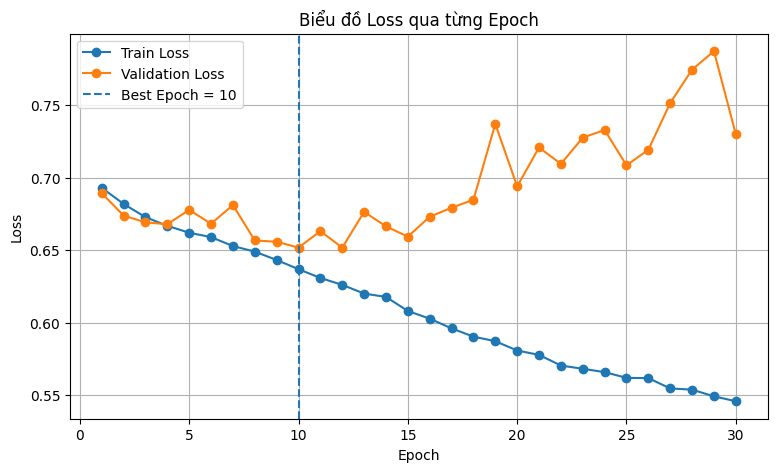

In [ ]:
# Tạo danh sách epoch thực tế đã chạy.
epochs = history_df["epoch"].values

# Tạo khung hình cho loss.
plt.figure(figsize=(9, 5))

# Vẽ train loss.
plt.plot(epochs, history_df["train_loss"], marker="o", label="Train Loss")

# Vẽ validation loss.
plt.plot(epochs, history_df["val_loss"], marker="o", label="Validation Loss")

# Vẽ đường dọc tại epoch tốt nhất.
plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")

# Đặt tiêu đề biểu đồ.
plt.title("Biểu đồ Loss qua từng Epoch")

# Đặt nhãn trục x.
plt.xlabel("Epoch")

# Đặt nhãn trục y.
plt.ylabel("Loss")

# Hiển thị chú thích.
plt.legend()

# Hiển thị lưới.
plt.grid(True)

# Lưu hình để đưa vào báo cáo.
plt.savefig("loss_curve.png", dpi=300, bbox_inches="tight")

# Hiển thị biểu đồ.
plt.show()

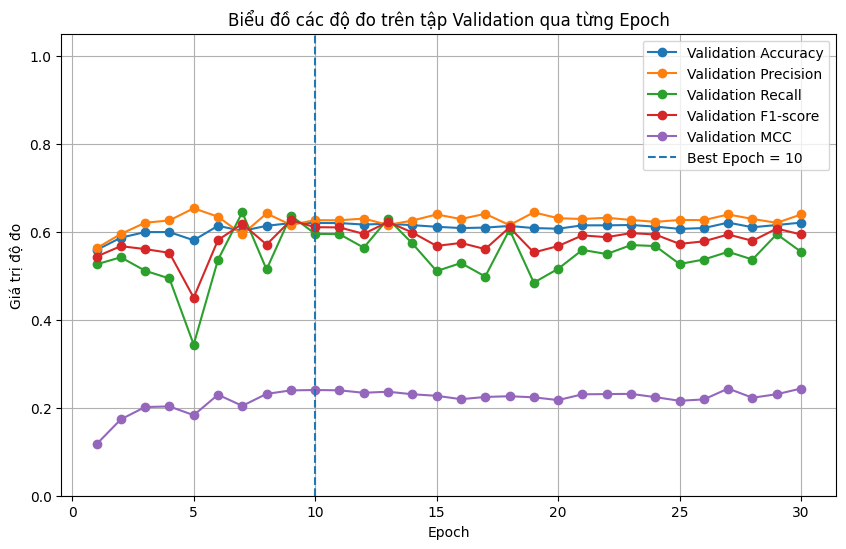

In [ ]:
# Tạo khung hình cho các metric validation.
plt.figure(figsize=(10, 6))

# Vẽ validation accuracy.
plt.plot(epochs, history_df["val_accuracy"], marker="o", label="Validation Accuracy")

# Vẽ validation precision.
plt.plot(epochs, history_df["val_precision"], marker="o", label="Validation Precision")

# Vẽ validation recall.
plt.plot(epochs, history_df["val_recall"], marker="o", label="Validation Recall")

# Vẽ validation F1-score.
plt.plot(epochs, history_df["val_f1"], marker="o", label="Validation F1-score")

# Vẽ validation MCC.
plt.plot(epochs, history_df["val_mcc"], marker="o", label="Validation MCC")

# Vẽ đường dọc tại epoch tốt nhất.
plt.axvline(best_epoch, linestyle="--", label=f"Best Epoch = {best_epoch}")

# Đặt tiêu đề biểu đồ.
plt.title("Biểu đồ các độ đo trên tập Validation qua từng Epoch")

# Đặt nhãn trục x.
plt.xlabel("Epoch")

# Đặt nhãn trục y.
plt.ylabel("Giá trị độ đo")

# Giới hạn trục y để dễ quan sát.
plt.ylim(0, 1.05)

# Hiển thị chú thích.
plt.legend()

# Hiển thị lưới.
plt.grid(True)

# Lưu hình.
plt.savefig("metrics_curve.png", dpi=300, bbox_inches="tight")

# Hiển thị hình.
plt.show()

<Figure size 600x500 with 0 Axes>

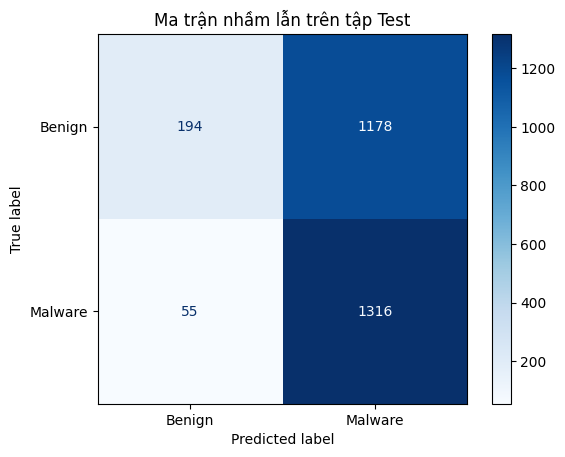

In [ ]:
# Tạo khung hình cho ma trận nhầm lẫn.
plt.figure(figsize=(6, 5))

# Tạo đối tượng hiển thị ma trận nhầm lẫn.
display = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malware"]
)

# Vẽ ma trận nhầm lẫn.
display.plot(values_format="d", cmap="Blues")

# Đặt tiêu đề.
plt.title("Ma trận nhầm lẫn trên tập Test")

# Lưu hình.
plt.savefig("confusion_matrix.png", dpi=300, bbox_inches="tight")

# Hiển thị hình.
plt.show()

<Figure size 600x500 with 0 Axes>

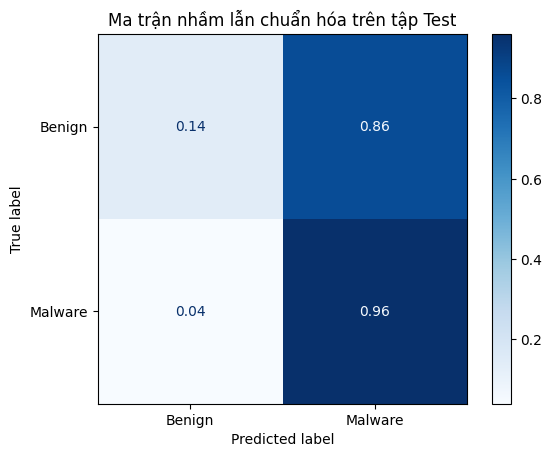

In [ ]:
# Tính ma trận nhầm lẫn chuẩn hóa theo từng hàng.
cm_normalized = confusion_matrix(y_true, y_pred, normalize="true")

# Tạo khung hình.
plt.figure(figsize=(6, 5))

# Tạo đối tượng hiển thị ma trận nhầm lẫn chuẩn hóa.
display_norm = ConfusionMatrixDisplay(
    confusion_matrix=cm_normalized,
    display_labels=["Benign", "Malware"]
)

# Vẽ ma trận chuẩn hóa.
display_norm.plot(values_format=".2f", cmap="Blues")

# Đặt tiêu đề.
plt.title("Ma trận nhầm lẫn chuẩn hóa trên tập Test")

# Lưu hình.
plt.savefig("confusion_matrix_normalized.png", dpi=300, bbox_inches="tight")

# Hiển thị hình.
plt.show()

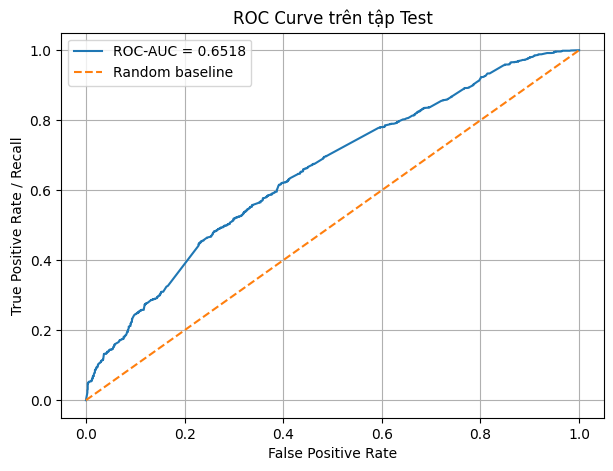

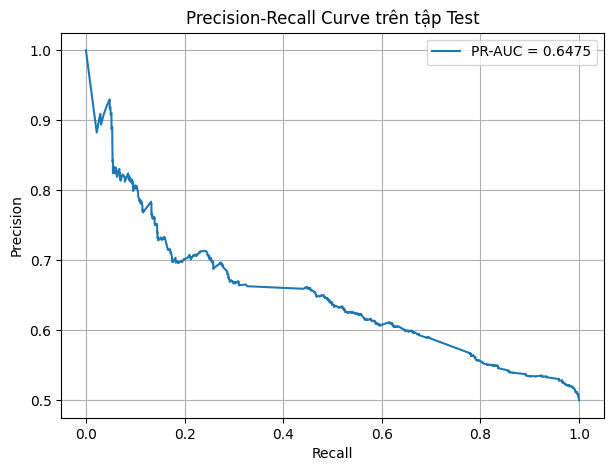

In [ ]:
# Vẽ ROC curve và Precision-Recall curve để đánh giá mô hình theo xác suất.
# Hai biểu đồ này bổ sung cho confusion matrix vì không phụ thuộc vào một threshold cố định.

# Tính ROC curve nếu tập test có đủ hai lớp.
fpr, tpr, _ = roc_curve(y_true, y_prob)

# Tạo hình ROC curve.
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {test_roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate / Recall")
plt.title("ROC Curve trên tập Test")
plt.legend()
plt.grid(True)
plt.savefig("roc_curve.png", dpi=300, bbox_inches="tight")
plt.show()

# Tính Precision-Recall curve.
precision_curve, recall_curve, _ = precision_recall_curve(y_true, y_prob)

# Tạo hình Precision-Recall curve.
plt.figure(figsize=(7, 5))
plt.plot(recall_curve, precision_curve, label=f"PR-AUC = {test_pr_auc:.4f}")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve trên tập Test")
plt.legend()
plt.grid(True)
plt.savefig("precision_recall_curve.png", dpi=300, bbox_inches="tight")
plt.show()


## 16. Phân tích overfitting tự động

Cell này giúp nhận xét nhanh quá trình train để đưa vào báo cáo.

In [ ]:
# Lấy epoch cuối cùng đã chạy.
last_epoch = int(history_df["epoch"].iloc[-1])

# Lấy train loss ở epoch đầu và cuối.
train_loss_start = history_df["train_loss"].iloc[0]
train_loss_end = history_df["train_loss"].iloc[-1]

# Lấy validation loss ở epoch đầu và cuối.
val_loss_start = history_df["val_loss"].iloc[0]
val_loss_end = history_df["val_loss"].iloc[-1]

# Kiểm tra dấu hiệu overfitting đơn giản.
overfitting_flag = (train_loss_end < train_loss_start) and (val_loss_end > val_loss_start)

# Tạo bảng nhận xét quá trình huấn luyện.
training_analysis = pd.DataFrame({
    "Nội dung": [
        "Epoch đã chạy",
        f"Epoch tốt nhất theo {EARLY_STOP_METRIC}",
        "Train loss epoch đầu",
        "Train loss epoch cuối",
        "Validation loss epoch đầu",
        "Validation loss epoch cuối",
        "Best validation F1-score quan sát được",
        "Best validation loss quan sát được",
        "Threshold tối ưu theo validation F1",
        "Test ROC-AUC",
        "Test PR-AUC",
        "Có dấu hiệu overfitting?"
    ],
    "Giá trị": [
        last_epoch,
        best_epoch,
        round(train_loss_start, 4),
        round(train_loss_end, 4),
        round(val_loss_start, 4),
        round(val_loss_end, 4),
        round(best_val_f1, 4),
        round(best_val_loss, 4),
        BEST_THRESHOLD,
        round(test_roc_auc, 4) if not np.isnan(test_roc_auc) else "N/A",
        round(test_pr_auc, 4) if not np.isnan(test_pr_auc) else "N/A",
        "Có" if overfitting_flag else "Chưa rõ"
    ]
})

# Lưu bảng phân tích.
training_analysis.to_csv("training_analysis.csv", index=False)

# Hiển thị bảng phân tích.
training_analysis


,Nội dung,Giá trị
0,Epoch đã chạy,30
1,Epoch tốt nhất theo val_loss,10
2,Train loss epoch đầu,0.693
3,Train loss epoch cuối,0.5458
4,Validation loss epoch đầu,0.6893
5,Validation loss epoch cuối,0.7298
6,Best validation F1-score quan sát được,0.626
7,Best validation loss quan sát được,0.6517
8,Threshold tối ưu theo validation F1,0.35
9,Test ROC-AUC,0.6518


## 17. Lưu mô hình, tokenizer và gói kết quả

In [ ]:
# Tạo thư mục lưu mô hình nếu chưa tồn tại.
os.makedirs("saved_model", exist_ok=True)

# Lưu trọng số mô hình tốt nhất đã được khôi phục sau early stopping.
torch.save(model.state_dict(), "saved_model/distilbertroid_permission_best.pt")

# Lưu tokenizer để tái sử dụng khi dự đoán app mới.
tokenizer.save_pretrained("saved_model/tokenizer")

# Lưu cấu hình thực nghiệm thành JSON để tái lập kết quả.
config_dict = {
    "model_name": MODEL_NAME,
    "max_len": MAX_LEN,
    "max_len_mode": MAX_LEN_MODE,
    "batch_size": BATCH_SIZE,
    "epochs_max": EPOCHS,
    "patience": PATIENCE,
    "early_stop_metric": EARLY_STOP_METRIC,
    "min_delta": MIN_DELTA,
    "encoder_lr": ENCODER_LR,
    "classifier_lr": CLASSIFIER_LR,
    "warmup_ratio": WARMUP_RATIO,
    "warmup_steps": num_warmup_steps,
    "weight_decay": WEIGHT_DECAY,
    "freeze_distilbert": FREEZE_DISTILBERT,
    "max_samples_per_class": MAX_SAMPLES_PER_CLASS,
    "samples_per_class_used": int(samples_per_class),
    "best_epoch": int(best_epoch),
    "best_metric_value": float(best_metric_value),
    "best_val_f1_observed": float(best_val_f1),
    "best_val_loss_observed": float(best_val_loss),
    "best_threshold": float(BEST_THRESHOLD),
    "test_roc_auc": float(test_roc_auc) if not np.isnan(test_roc_auc) else None,
    "test_pr_auc": float(test_pr_auc) if not np.isnan(test_pr_auc) else None,
    "use_amp": USE_AMP,
    "fast_training": FAST_TRAINING,
    "device": str(device)
}

# Ghi file cấu hình ra experiment_config.json.
with open("experiment_config.json", "w", encoding="utf-8") as f:
    json.dump(config_dict, f, ensure_ascii=False, indent=2)

# In thông báo hoàn tất lưu mô hình và cấu hình.
print("Đã lưu mô hình, tokenizer và cấu hình thực nghiệm.")


Đã lưu mô hình, tokenizer và cấu hình thực nghiệm.


In [ ]:
# Danh sách file kết quả cần nộp kèm.
files_to_zip = [
    "permissions_dataset.csv",
    "permissions_dataset_experiment.csv",
    "data_summary.csv",
    "split_summary.csv",
    "training_config.csv",
    "training_history.csv",
    "best_epoch_summary.csv",
    "threshold_tuning.csv",
    "test_results.csv",
    "classification_report.txt",
    "classification_report.csv",
    "confusion_matrix_table.csv",
    "comparison_with_bertroid.csv",
    "training_analysis.csv",
    "loss_curve.png",
    "metrics_curve.png",
    "confusion_matrix.png",
    "confusion_matrix_normalized.png",
    "roc_curve.png",
    "precision_recall_curve.png",
    "experiment_config.json",
    "saved_model/distilbertroid_permission_best.pt"
]

# Tên file zip kết quả.
zip_name = "B9D54_10_Tran_Van_Quang_Khai_ATMobile_optimized_results.zip"

# Tạo file zip.
with zipfile.ZipFile(zip_name, "w", zipfile.ZIP_DEFLATED) as zipf:
    # Duyệt từng file trong danh sách.
    for file_path in files_to_zip:
        # Nếu file tồn tại thì thêm vào zip.
        if os.path.exists(file_path):
            zipf.write(file_path)

    # Nén cả thư mục tokenizer nếu có.
    if os.path.exists("saved_model/tokenizer"):
        for root, dirs, files in os.walk("saved_model/tokenizer"):
            for file in files:
                full_path = os.path.join(root, file)
                zipf.write(full_path)

# In thông báo hoàn tất.
print("Đã tạo file zip:", zip_name)


Đã tạo file zip: B9D54_10_Tran_Van_Quang_Khai_ATMobile_optimized_results.zip


## 18. Hàm dự đoán một ứng dụng mới

Cell này dùng để demo mô hình sau khi huấn luyện. Đầu vào là chuỗi permission của một ứng dụng mới.

In [ ]:
# Hàm dự đoán một chuỗi permission mới.
def predict_permission_text(permission_text, model, tokenizer, device, max_len=MAX_LEN, threshold=BEST_THRESHOLD):
    # Chuyển mô hình sang chế độ đánh giá.
    model.eval()

    # Chuẩn hóa chuỗi permission đầu vào.
    permission_text = str(permission_text).lower().strip()

    # Tokenize chuỗi permission.
    encoding = tokenizer(
        permission_text,
        add_special_tokens=True,
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_attention_mask=True,
        return_tensors="pt"
    )

    # Chuyển input_ids sang thiết bị đang dùng.
    input_ids = encoding["input_ids"].to(device)

    # Chuyển attention_mask sang thiết bị đang dùng.
    attention_mask = encoding["attention_mask"].to(device)

    # Không tính gradient khi dự đoán.
    with torch.no_grad():
        # Bật autocast nếu dùng GPU.
        with get_autocast_context(device, enabled=USE_AMP):
            # Forward qua mô hình.
            logits = model(input_ids=input_ids, attention_mask=attention_mask)

        # Tính xác suất bằng softmax.
        probs = torch.softmax(logits.float(), dim=1)

        # Lấy xác suất lớp malware.
        malware_prob = probs[0, 1].item()

        # Dự đoán theo threshold tối ưu đã tìm trên validation set.
        pred = int(malware_prob >= threshold)

    # Chuyển nhãn số sang tên lớp.
    label_name = "Malware" if pred == 1 else "Benign"

    return label_name, malware_prob

# Ví dụ kiểm thử nhanh.
sample_permission = "internet read_sms send_sms receive_sms read_contacts"

# Dự đoán mẫu.
label, malware_prob = predict_permission_text(sample_permission, model, tokenizer, device)

# In kết quả.
print("Permission:", sample_permission)
print("Dự đoán:", label)
print("Xác suất Malware:", round(malware_prob, 4))
print("Threshold đang dùng:", BEST_THRESHOLD)


Permission: internet read_sms send_sms receive_sms read_contacts
Dự đoán: Malware
Xác suất Malware: 0.4354
Threshold đang dùng: 0.35
